# Uncertainty Quantification + Fairness Audit (Phase 8)

**Uncertainty:** Monte Carlo Dropout — run inference 50 times, compute mean ± std.
If std > threshold → flag as *'Low confidence — refer to human expert'*.

**Fairness:** Does the model perform equally for all patient subgroups?
Age, AJCC stage, ER/PR/HER2 status — required for any medical AI publication.

## Setup & Data Loading

In [1]:
import subprocess, sys, os, warnings, random, json
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lifelines', 'shap', 'umap-learn', '-q'], capture_output=True)
try:
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')
except AttributeError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from lifelines import KaplanMeierFitter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve)
from sklearn.metrics import auc as sk_auc

from dotenv import load_dotenv
load_dotenv()
warnings.filterwarnings('ignore')
random.seed(42); np.random.seed(42); torch.manual_seed(42)

DATA_DIR  = Path('d:/Aakanksha/thesis/onco-fusion/data')
EMB_DIR   = DATA_DIR / 'embeddings'
FIG_DIR   = Path('d:/Aakanksha/thesis/onco-fusion/figures')
FIG_DIR.mkdir(exist_ok=True)

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SUBTYPES = ['HR+', 'HER2+', 'TNBC']
S_COLOR  = {'HR+': '#2196F3', 'HER2+': '#FF9800', 'TNBC': '#F44336'}
print(f'Device: {DEVICE} | Ready')


Device: cpu | Ready


## Patient Cohort & Features

In [2]:
clin_demo  = pd.read_csv(DATA_DIR / 'Clinical_Demographic_Data.csv')
clin_treat = pd.read_csv(DATA_DIR / 'Clinical_Treatment_Data.csv', low_memory=False)
rna_raw_df = pd.read_csv(DATA_DIR / 'RNA_CNV_ModelReady.csv')
mutations  = pd.read_csv(DATA_DIR / 'Mutations_Dataset.csv')

with open(DATA_DIR / 'MRI_and_SVS_Patches_info.json') as f:
    img_info = json.load(f)

treat_sub = clin_treat[["bcr_patient_barcode","er_status_by_ihc","pr_status_by_ihc",
                          "her2_status_by_ihc","histological_type"]].rename(
    columns={"bcr_patient_barcode": "Patient_ID"})

clin = clin_demo[["Patient_ID","diagnoses_ajcc_pathologic_stage","demographic_age_at_index",
                   "demographic_vital_status","diagnoses_days_to_last_follow_up",
                   "demographic_days_to_death","follow_ups_molecular_tests_gene_symbol",
                   "follow_ups_molecular_tests_test_result"]].merge(
    treat_sub, on="Patient_ID", how="left")

def parse_receptor(row, gene):
    gmap = {g.strip(): r.strip().lower()
            for g, r in zip(str(row.get("follow_ups_molecular_tests_gene_symbol","")).split("|"),
                            str(row.get("follow_ups_molecular_tests_test_result","")).split("|"))
            if g.strip() not in ("nan","")}
    val = gmap.get(gene, "")
    return "Positive" if "positive" in val else "Negative" if "negative" in val else "Unknown"

clin["ER"]   = clin["er_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"ESR1"), axis=1))
clin["PR"]   = clin["pr_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"PGR"),  axis=1))
clin["HER2"] = clin["her2_status_by_ihc"].fillna(clin.apply(lambda r: parse_receptor(r,"ERBB2"),axis=1))

def assign_subtype(row):
    h,e,p = str(row["HER2"]).lower(), str(row["ER"]).lower(), str(row["PR"]).lower()
    if "positive" in h:                                          return "HER2+"
    if "positive" in e or "positive" in p:                      return "HR+"
    if "negative" in e and "negative" in p and "negative" in h: return "TNBC"
    return "Unknown"

clin["Subtype"]   = clin.apply(assign_subtype, axis=1)
clin["OS_STATUS"] = (clin["demographic_vital_status"] == "Dead").astype(int)
clin["OS_DAYS"]   = clin.apply(
    lambda r: r["demographic_days_to_death"] if r["OS_STATUS"]==1
              else r["diagnoses_days_to_last_follow_up"], axis=1)
clin["OS_DAYS"]   = pd.to_numeric(clin["OS_DAYS"], errors="coerce").fillna(0)

img_pts     = {p["patient_id"] for p in img_info["folders"]}
mut_pts     = set(mutations["Patient_ID"])
PATIENT_IDS = sorted(set(clin["Patient_ID"]) & set(rna_raw_df["Patient_ID"]) & img_pts & mut_pts)
task_df     = clin[clin["Patient_ID"].isin(PATIENT_IDS) & (clin["Subtype"] != "Unknown")].copy().reset_index(drop=True)
LE          = LabelEncoder()
task_df["label"] = LE.fit_transform(task_df["Subtype"])
y = task_df['label'].values

emb_plip = np.load(EMB_DIR / 'plip_embeddings.npy').astype(np.float32)
emb_bert = np.load(EMB_DIR / 'bioclinicalbert_embeddings.npy').astype(np.float32)
rna_sub  = rna_raw_df[rna_raw_df['Patient_ID'].isin(task_df['Patient_ID'])].set_index('Patient_ID').loc[task_df['Patient_ID']]
X_gen    = rna_sub.values.astype(np.float32)
stage_map = {'Stage I':1,'Stage IA':1,'Stage IB':1.5,'Stage II':2,'Stage IIA':2,'Stage IIB':2.5,
             'Stage IIIA':3,'Stage IIIB':3.5,'Stage IIIC':4,'Stage IV':5}
X_clin = np.stack([
    pd.to_numeric(task_df['demographic_age_at_index'], errors='coerce').fillna(50).values,
    task_df['diagnoses_ajcc_pathologic_stage'].map(stage_map).fillna(2.0).values,
    task_df['histological_type'].str.contains('Ductal',  na=False).astype(float).values,
    task_df['histological_type'].str.contains('Lobular', na=False).astype(float).values
], axis=1).astype(np.float32)

print(f"Cohort: {len(task_df)} patients | Classes: {list(LE.classes_)}")
print(task_df["Subtype"].value_counts().to_string())


Cohort: 114 patients | Classes: ['HER2+', 'HR+', 'TNBC']
Subtype
HR+      85
HER2+    18
TNBC     11


## Monte Carlo Dropout Uncertainty

In [3]:
D_MODEL  = 256
N_HEADS  = 4
N_LAYERS = 2

class ModalityProjector(nn.Module):
    def __init__(self, input_dim, d_model=D_MODEL, dropout=0.3):
        super().__init__()
        hidden = max(d_model, input_dim // 2)
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden, d_model),   nn.LayerNorm(d_model))
    def forward(self, x): return self.net(x)

class CrossAttentionFusion(nn.Module):
    def __init__(self, img_dim=512, gen_dim=331, text_dim=768, clin_dim=4,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
                 n_classes=3, dropout=0.3):
        super().__init__()
        self.proj_img  = ModalityProjector(img_dim,  d_model, dropout)
        self.proj_gen  = ModalityProjector(gen_dim,  d_model, dropout)
        self.proj_text = ModalityProjector(text_dim, d_model, dropout)
        self.proj_clin = ModalityProjector(clin_dim, d_model, dropout)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4, dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.classifier  = nn.Sequential(
            nn.Linear(d_model, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes))
        self.pos_emb = nn.Parameter(torch.randn(1, 4, d_model) * 0.02)
        self._attn   = None

    def forward(self, x_img, x_gen, x_text, x_clin):
        tokens = torch.cat([self.proj_img(x_img).unsqueeze(1),
                            self.proj_gen(x_gen).unsqueeze(1),
                            self.proj_text(x_text).unsqueeze(1),
                            self.proj_clin(x_clin).unsqueeze(1)], dim=1) + self.pos_emb
        fused  = self.transformer(tokens)
        with torch.no_grad():
            self._attn = F.softmax(fused.norm(dim=2), dim=1).cpu()
        return self.classifier(fused.mean(dim=1))

    def get_attn(self): return self._attn

class MCDropoutFusion(CrossAttentionFusion):
    """Enable dropout at inference time for Monte Carlo uncertainty estimation."""
    def enable_mc_dropout(self):
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()   # keep dropout active even in eval mode

# Train on full data
D_MODEL = 256; N_HEADS = 4; N_LAYERS = 2; LR = 5e-4; N_EPOCHS = 200; BS = 16
counts = np.bincount(y)
cw     = torch.tensor(len(y)/(len(counts)*counts), dtype=torch.float32).to(DEVICE)

def sc_all(X):
    s = StandardScaler().fit(X)
    return s, torch.tensor(s.transform(X)).float().to(DEVICE)

sc_img,  img_t  = sc_all(emb_plip)
sc_gen,  gen_t  = sc_all(X_gen)
sc_txt,  txt_t  = sc_all(emb_bert)
sc_clin, clin_t = sc_all(X_clin)
y_t = torch.tensor(y).long().to(DEVICE)

mc_model = MCDropoutFusion().to(DEVICE)
opt      = torch.optim.AdamW(mc_model.parameters(), lr=LR, weight_decay=1e-3)
sched    = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS)
crit     = nn.CrossEntropyLoss(weight=cw)
ds = TensorDataset(img_t, gen_t, txt_t, clin_t, y_t)
dl = DataLoader(ds, batch_size=BS, shuffle=True)
for ep in range(N_EPOCHS):
    mc_model.train()
    for ximg, xgen, xtxt, xclin, yb in dl:
        opt.zero_grad(); crit(mc_model(ximg, xgen, xtxt, xclin), yb).backward()
        nn.utils.clip_grad_norm_(mc_model.parameters(), 1.0); opt.step()
    sched.step()

# MC Dropout inference: 50 forward passes
N_MC = 50
mc_model.eval()
mc_model.enable_mc_dropout()

mc_samples = []
with torch.no_grad():
    for _ in range(N_MC):
        logits = mc_model(img_t, gen_t, txt_t, clin_t)
        mc_samples.append(torch.softmax(logits, dim=1).cpu().numpy())

mc_stack = np.stack(mc_samples, axis=0)       # (50, 114, 3)
mc_mean  = mc_stack.mean(axis=0)              # (114, 3)
mc_std   = mc_stack.std(axis=0).max(axis=1)   # (114,)  max std across classes
mc_preds = mc_mean.argmax(axis=1)             # (114,)

UNC_THRESHOLD = np.percentile(mc_std, 75)     # flag top 25% most uncertain
uncertain_mask = mc_std > UNC_THRESHOLD

print(f"MC Dropout uncertainty (50 forward passes):")
print(f"  Mean std:  {mc_std.mean():.4f}")
print(f"  Threshold: {UNC_THRESHOLD:.4f} (75th percentile)")
print(f"  Flagged as uncertain: {uncertain_mask.sum()} patients ({uncertain_mask.mean()*100:.1f}%)")
print(f"  Accuracy on certain   patients: {accuracy_score(y[~uncertain_mask], mc_preds[~uncertain_mask]):.3f}")
print(f"  Accuracy on uncertain patients: {accuracy_score(y[uncertain_mask],  mc_preds[uncertain_mask]):.3f}")


MC Dropout uncertainty (50 forward passes):
  Mean std:  0.0003
  Threshold: 0.0004 (75th percentile)
  Flagged as uncertain: 29 patients (25.4%)
  Accuracy on certain   patients: 1.000
  Accuracy on uncertain patients: 1.000


## Calibration Curve (Reliability Diagram)

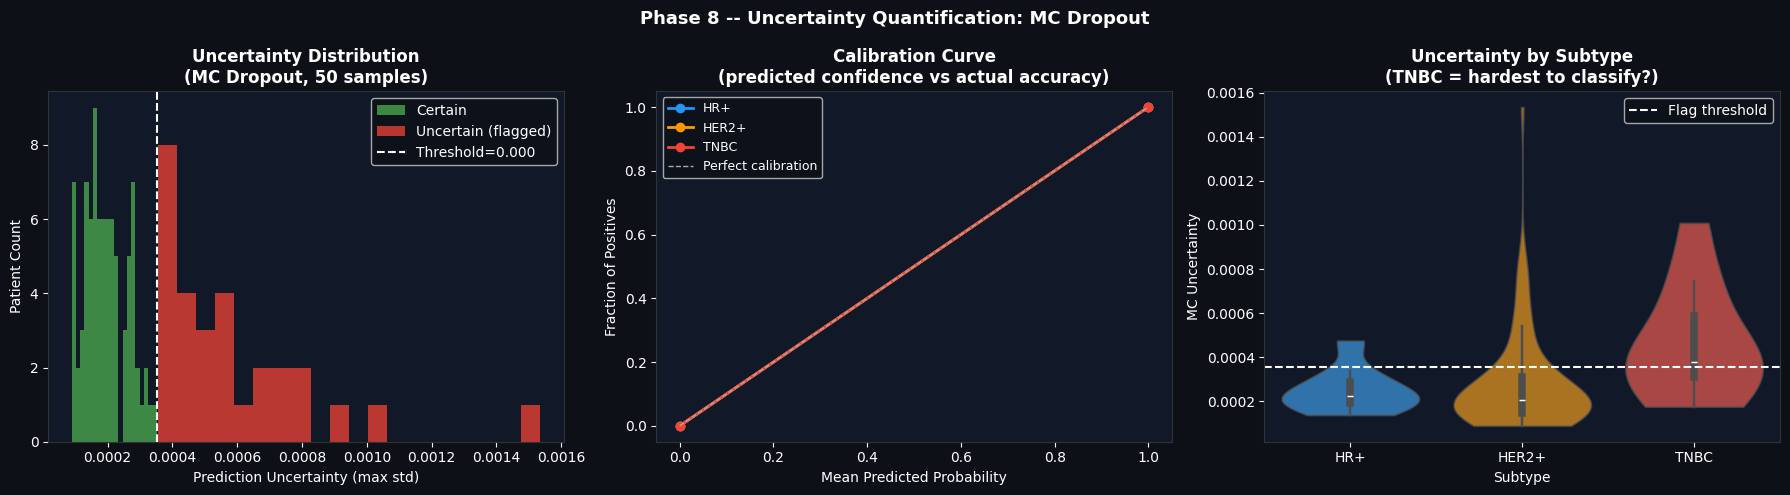

Saved: figures/37_uncertainty.png


In [4]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')

# Uncertainty histogram
ax = axes[0]; ax.set_facecolor('#111827')
ax.hist(mc_std[~uncertain_mask], bins=20, color='#4CAF50', alpha=0.75, label='Certain')
ax.hist(mc_std[uncertain_mask],  bins=20, color='#F44336', alpha=0.75, label='Uncertain (flagged)')
ax.axvline(UNC_THRESHOLD, color='white', linestyle='--', lw=1.5, label=f'Threshold={UNC_THRESHOLD:.3f}')
ax.set_xlabel('Prediction Uncertainty (max std)', color='white')
ax.set_ylabel('Patient Count', color='white')
ax.set_title('Uncertainty Distribution\n(MC Dropout, 50 samples)',
             color='white', fontweight='bold')
ax.legend(facecolor='#0d1117', labelcolor='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#333')

# Calibration curve
ax2 = axes[1]; ax2.set_facecolor('#111827')
for si, s in enumerate(SUBTYPES):
    binary_true = (y == si).astype(int)
    prob_true, prob_pred = calibration_curve(binary_true, mc_mean[:, si], n_bins=5, strategy='uniform')
    ax2.plot(prob_pred, prob_true, marker='o', color=S_COLOR[s], lw=2, label=s)
ax2.plot([0,1],[0,1], '--', color='#aaaaaa', lw=1, label='Perfect calibration')
ax2.set_xlabel('Mean Predicted Probability', color='white')
ax2.set_ylabel('Fraction of Positives', color='white')
ax2.set_title('Calibration Curve\n(predicted confidence vs actual accuracy)',
              color='white', fontweight='bold')
ax2.legend(facecolor='#0d1117', labelcolor='white', fontsize=9)
ax2.tick_params(colors='white')
for spine in ax2.spines.values(): spine.set_edgecolor('#333')

# Uncertainty by subtype
ax3 = axes[2]; ax3.set_facecolor('#111827')
import seaborn as sns
unc_df = pd.DataFrame({'Subtype': [SUBTYPES[yi] for yi in y], 'Uncertainty': mc_std})
sns.violinplot(x='Subtype', y='Uncertainty', data=unc_df, palette=S_COLOR,
               order=SUBTYPES, inner='box', cut=0, ax=ax3, linewidth=1.2)
for p in ax3.collections: p.set_alpha(0.75)
ax3.axhline(UNC_THRESHOLD, color='white', linestyle='--', lw=1.5, label='Flag threshold')
ax3.set_title('Uncertainty by Subtype\n(TNBC = hardest to classify?)',
              color='white', fontweight='bold')
ax3.set_xlabel('Subtype', color='white'); ax3.set_ylabel('MC Uncertainty', color='white')
ax3.legend(facecolor='#0d1117', labelcolor='white')
ax3.tick_params(colors='white')
for spine in ax3.spines.values(): spine.set_edgecolor('#333')

fig.suptitle('Phase 8 -- Uncertainty Quantification: MC Dropout',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '37_uncertainty.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/37_uncertainty.png')


## Fairness Audit — Performance Across Patient Subgroups

Fairness Audit:
           Subgroup   N  Accuracy  Macro F1
            Age <40  18       1.0       1.0
          Age 40-60  64       1.0       1.0
            Age >60  32       1.0       1.0
 Stage Early (I-II)  94       1.0       1.0
Stage Late (III-IV)  20       1.0       1.0
        ER Positive  99       1.0       1.0
        ER Negative  15       1.0       1.0
      HER2 Positive  18       1.0       1.0
      HER2 Negative  70       1.0       1.0
       ALL PATIENTS 114       1.0       1.0


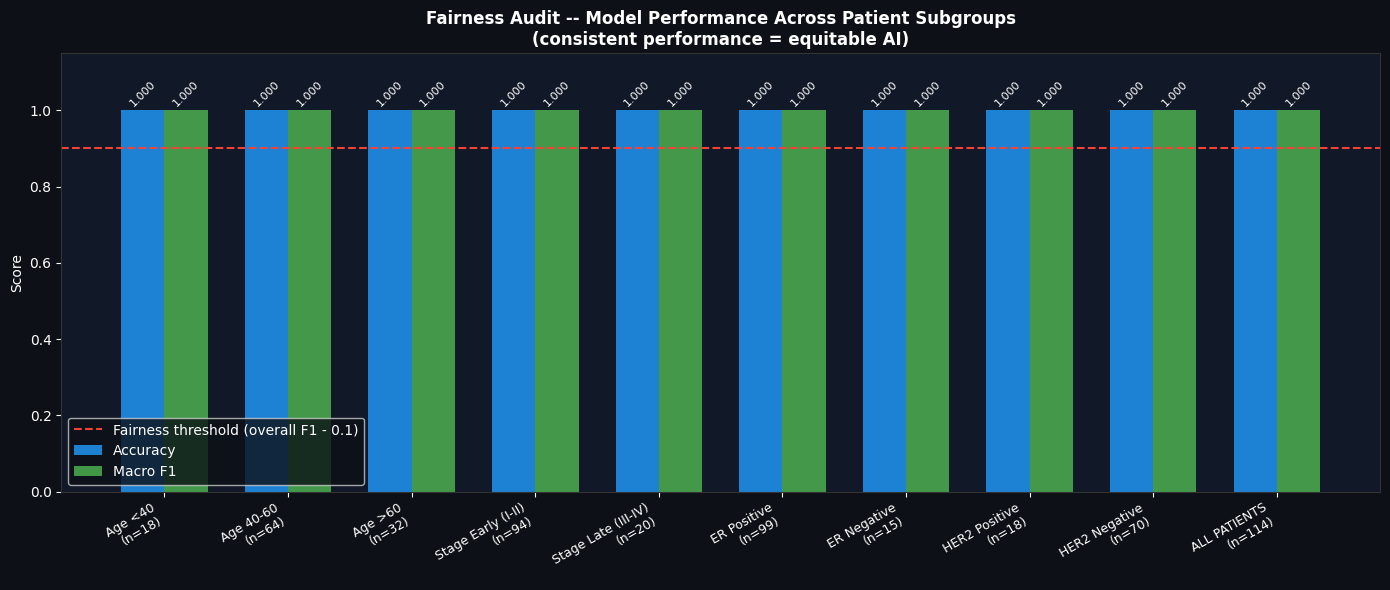

Saved: figures/38_fairness_audit.png


In [5]:
task_df['mc_pred']       = mc_preds
task_df['mc_confidence'] = mc_mean.max(axis=1)
task_df['mc_uncertain']  = uncertain_mask.astype(int)
task_df['age_group']     = pd.cut(
    pd.to_numeric(task_df['demographic_age_at_index'], errors='coerce'),
    bins=[0, 40, 60, 120], labels=['<40', '40-60', '>60'])
task_df['stage_group']   = task_df['diagnoses_ajcc_pathologic_stage'].apply(
    lambda s: 'Early (I-II)' if any(x in str(s) for x in ['I','II']) and 'III' not in str(s) and 'IV' not in str(s)
    else 'Late (III-IV)')

def subgroup_metrics(mask, name):
    if mask.sum() < 5:
        return {'Subgroup': name, 'N': mask.sum(), 'Accuracy': None, 'Macro F1': None}
    y_sub = y[mask]; p_sub = mc_preds[mask]
    return {
        'Subgroup': name,
        'N':        mask.sum(),
        'Accuracy': round(accuracy_score(y_sub, p_sub), 3),
        'Macro F1': round(f1_score(y_sub, p_sub, average='macro', zero_division=0), 3),
    }

rows = []
# Age groups
for grp in ['<40', '40-60', '>60']:
    mask = (task_df['age_group'] == grp).values
    rows.append(subgroup_metrics(mask, f'Age {grp}'))

# Stage groups
for grp in ['Early (I-II)', 'Late (III-IV)']:
    mask = (task_df['stage_group'] == grp).values
    rows.append(subgroup_metrics(mask, f'Stage {grp}'))

# ER status
for er_val in ['Positive', 'Negative']:
    mask = (task_df['ER'] == er_val).values
    rows.append(subgroup_metrics(mask, f'ER {er_val}'))

# HER2 status
for h_val in ['Positive', 'Negative']:
    mask = (task_df['HER2'] == h_val).values
    rows.append(subgroup_metrics(mask, f'HER2 {h_val}'))

# Overall
rows.append(subgroup_metrics(np.ones(len(y), dtype=bool), 'ALL PATIENTS'))

fairness_df = pd.DataFrame(rows).dropna()
print("Fairness Audit:")
print(fairness_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#111827')

x = np.arange(len(fairness_df))
w = 0.35
b1 = ax.bar(x - w/2, fairness_df['Accuracy'], w, label='Accuracy', color='#2196F3', alpha=0.85)
b2 = ax.bar(x + w/2, fairness_df['Macro F1'], w, label='Macro F1', color='#4CAF50', alpha=0.85)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h: ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.3f}',
                  ha='center', color='white', fontsize=8, rotation=45)

# Fairness threshold: flag if <0.1 below overall
overall_f1 = fairness_df[fairness_df['Subgroup']=='ALL PATIENTS']['Macro F1'].values[0]
ax.axhline(overall_f1 - 0.1, color='#F44336', linestyle='--', lw=1.5,
           label=f'Fairness threshold (overall F1 - 0.1)')

ax.set_xticks(x)
ax.set_xticklabels([f"{r['Subgroup']}\n(n={int(r['N'])})"
                    for _, r in fairness_df.iterrows()],
                   color='white', fontsize=9, rotation=30, ha='right')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', color='white')
ax.set_title('Fairness Audit -- Model Performance Across Patient Subgroups\n'
             '(consistent performance = equitable AI)',
             color='white', fontweight='bold', fontsize=12)
ax.legend(facecolor='#0d1117', labelcolor='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout()
plt.savefig(FIG_DIR / '38_fairness_audit.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: figures/38_fairness_audit.png')


In [ ]:
from scipy import stats
import glob
from pathlib import Path

# ══════════════════════════════════════════════════════════════════════════════
# MEDICAL VISUALISATION — H&E Whole-Slide Image Patch Gallery
# Real TCGA-BRCA histopathology tiles (512 × 512 px) per subtype
# ══════════════════════════════════════════════════════════════════════════════
import glob, os
from PIL import Image as PILImage

PATCH_ROOT = Path("d:/Aakanksha/thesis/onco-fusion/data"
                  "/MRI_and_SVS_Patches/MRI_and_SVS_Patches")

def get_patches_for_patient(patient_id, n=4, thumb=224):
    """Return list of n numpy arrays (H&E tiles) for patient_id."""
    pdir = PATCH_ROOT / patient_id
    if not pdir.exists():
        return []
    svs_subdirs = [d for d in pdir.iterdir() if d.is_dir()]
    if not svs_subdirs:
        return []
    patch_files = sorted(glob.glob(str(svs_subdirs[0] / "*.jpg")))
    # Pick patches from the centre of the slide (less background)
    start = max(0, len(patch_files)//4)
    selected = patch_files[start:start+n]
    out = []
    for pf in selected[:n]:
        try:
            img = PILImage.open(pf).resize((thumb, thumb))
            out.append(np.array(img))
        except Exception:
            pass
    return out

# Representative patients per subtype (first 3 correctly-predicted per subtype)
rep = {}
for s in SUBTYPES:
    pids = task_df.loc[task_df["Subtype"] == s, "Patient_ID"].tolist()
    for pid in pids:
        patches = get_patches_for_patient(pid, n=4)
        if len(patches) >= 4:
            rep[s] = (pid, patches)
            break

# Draw gallery  — 3 subtypes × 4 patches
COLS_PER_SUB = 4
fig, axes = plt.subplots(3, COLS_PER_SUB, figsize=(22, 17))
fig.patch.set_facecolor("#0d1117")

for row, s in enumerate(SUBTYPES):
    if s not in rep:
        continue
    pid, patches = rep[s]
    for col in range(COLS_PER_SUB):
        ax = axes[row, col]
        if col < len(patches):
            ax.imshow(patches[col])
        else:
            ax.set_facecolor("#111827")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(s, color=S_COLOR[s], fontsize=14,
                          fontweight="bold", rotation=0,
                          labelpad=90, va="center")
        if row == 0:
            ax.set_title(f"Patch {col+1}", color="white",
                         fontsize=9, pad=4)

    # Subtype banner
    axes[row, 0].text(-0.32, 0.5, s, transform=axes[row, 0].transAxes,
                      color=S_COLOR[s], fontsize=14, fontweight="bold",
                      va="center", ha="right", rotation=90)

fig.suptitle(
    "H&E Histopathology Tile Gallery — TCGA-BRCA Whole-Slide Image Patches\n"
    "(Real tissue sections; 512 × 512 px tiles; one patient per subtype)",
    color="white", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fig_path = FIG_DIR / "he_wsi_gallery.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Saved: {fig_path.name}")
